# Dataset Exploration: Forest Fire and Smoke Detection

**Course:** CS437/CS5317/EE414/EE513 — Deep Learning, Spring 2026  
**Group 4:** Muhammad Baqir Hassan Babar (27100340) & Momin Fahed Khan (27100082)

**Project:** Reducing False Positives in Real-Time Forest Fire and Smoke Detection via Semantic Verification

---

## Overview

This notebook documents the datasets used in our project:

1. **D-Fire** (primary benchmark) — 21,527 RGB images with fire and smoke bounding-box annotations
2. **FASDD** (secondary benchmark) — 100k+ heterogeneous fire/smoke images from multiple sources
3. **WWF PTZ Camera Dataset** (deployment dataset) — Real-world forest monitoring footage (custom, in progress)

We cover: class definitions, train/test splits, annotation format, sample visualization, class distribution analysis, and annotation quality checks.


## 1. Environment Setup

In [1]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
random.seed(42)
np.random.seed(42)

print("Environment ready.")


Environment ready.


## 2. Dataset Acquisition

### 2.1 D-Fire Dataset

**Source:** https://github.com/gaiasd/DFireDataset  
**Paper:** de Venâncio et al., "An automatic fire detection system based on deep convolutional neural networks for low-power, resource-constrained devices," *Neural Computing and Applications*, 2022.

The D-Fire dataset contains **21,527 images** with bounding-box annotations for two classes: **fire** and **smoke**. It is the largest publicly available fire+smoke detection benchmark with hard negatives (lamp lights, sun glare, reflective surfaces).

**To download:**
```bash
git clone https://github.com/gaiasd/DFireDataset.git
```

Or download the zip from the GitHub releases page. After extraction, the structure is:
```
DFireDataset/
├── train/
│   ├── images/
│   └── labels/
└── test/
    ├── images/
    └── labels/
```


In [2]:
# ── CONFIGURE THIS PATH ──
# Point this to wherever you extracted/cloned the D-Fire dataset.
DFIRE_ROOT = "/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data"  # <-- CHANGE THIS if your path differs
val_img_dir = os.path.join(DFIRE_ROOT, "val", "images")
val_lbl_dir = os.path.join(DFIRE_ROOT, "val", "labels")
# Verify structure
train_img_dir = os.path.join(DFIRE_ROOT, "train", "images")
train_lbl_dir = os.path.join(DFIRE_ROOT, "train", "labels")
test_img_dir  = os.path.join(DFIRE_ROOT, "test", "images")
test_lbl_dir  = os.path.join(DFIRE_ROOT, "test", "labels")

for d in [train_img_dir, train_lbl_dir, test_img_dir, test_lbl_dir]:
    exists = os.path.isdir(d)
    print(f"{'[OK]' if exists else '[MISSING]'} {d}")

if not os.path.isdir(train_img_dir):
    print("\n⚠ Dataset not found at the specified path.")
    print("  Download it from: https://github.com/gaiasd/DFireDataset")
    print("  Then update DFIRE_ROOT above.")


[OK] /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/train/images
[OK] /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/train/labels
[OK] /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images
[OK] /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/labels


## 3. Class Definitions and Annotation Format

### 3.1 D-Fire Classes

| Class ID | Class Name | Description |
|----------|-----------|-------------|
| 0 | **Smoke** | Smoke plumes, haze from combustion |
| 1 | **Fire** | Open flames, burning regions, embers |

Images with **no annotations** (empty label files) represent **negative samples** — scenes without fire or smoke, including hard negatives like sunlight, fog, lamp lights, and reflective surfaces.

### 3.2 Annotation Format (YOLO)

Each `.txt` label file contains zero or more lines, each representing one bounding box:

```
<class_id> <x_center> <y_center> <width> <height>
```

All coordinates are **normalized** to [0, 1] relative to image dimensions.

Example:
```
0 0.4531 0.3125 0.1562 0.2083
1 0.7266 0.6042 0.2344 0.1875
```
This means: one smoke box centered at (45.3%, 31.3%) of image width/height, and one fire box centered at (72.7%, 60.4%).


## 4. Dataset Statistics

In [3]:
from tqdm import tqdm
import glob

def count_images_and_labels_fast(img_dir, lbl_dir, split_name=""):
    label_files = glob.glob(os.path.join(lbl_dir, "*.txt"))
    image_files = set(os.path.splitext(os.path.basename(f))[0] 
                      for f in glob.glob(os.path.join(img_dir, "*.*")))
    
    stats = {
        'total_images': len(image_files),
        'fire_only': 0, 'smoke_only': 0, 'fire_and_smoke': 0, 'negative': 0,
        'total_fire_boxes': 0, 'total_smoke_boxes': 0,
        'boxes_per_image': [], 'box_sizes': [], 'class_ids': []
    }
    
    labeled_bases = set()
    for lbl_path in tqdm(label_files, desc=f"Scanning {split_name}", unit="file"):
        base = os.path.splitext(os.path.basename(lbl_path))[0]
        labeled_bases.add(base)
        
        with open(lbl_path, 'r') as f:
            content = f.read().strip()
        
        if not content:
            stats['negative'] += 1
            stats['boxes_per_image'].append(0)
            continue
        
        has_fire = has_smoke = False
        n_boxes = 0
        for line in content.split('\n'):
            parts = line.split()
            if len(parts) >= 5:
                cls_id = int(parts[0])
                w, h = float(parts[3]), float(parts[4])
                stats['class_ids'].append(cls_id)
                stats['box_sizes'].append((w, h))
                n_boxes += 1
                if cls_id == 1:
                    has_fire = True
                    stats['total_fire_boxes'] += 1
                elif cls_id == 0:
                    has_smoke = True
                    stats['total_smoke_boxes'] += 1
        
        stats['boxes_per_image'].append(n_boxes)
        if has_fire and has_smoke:
            stats['fire_and_smoke'] += 1
        elif has_fire:
            stats['fire_only'] += 1
        elif has_smoke:
            stats['smoke_only'] += 1
        else:
            stats['negative'] += 1
    
    unlabeled = image_files - labeled_bases
    stats['negative'] += len(unlabeled)
    stats['boxes_per_image'].extend([0] * len(unlabeled))
    
    return stats

if os.path.isdir(train_img_dir):
    train_stats = count_images_and_labels_fast(train_img_dir, train_lbl_dir, "train")
    test_stats  = count_images_and_labels_fast(test_img_dir, test_lbl_dir, "test")
    val_stats   = count_images_and_labels_fast(val_img_dir, val_lbl_dir, "val")
    
    print("\n" + "=" * 70)
    print("D-FIRE DATASET SUMMARY")
    print("=" * 70)
    print(f"{'Metric':<35} {'Train':>10} {'Val':>10} {'Test':>10}")
    print("-" * 70)
    for key, label in [('total_images','Total images'), ('fire_only','Fire-only images'),
                       ('smoke_only','Smoke-only images'), ('fire_and_smoke','Fire+Smoke images'),
                       ('negative','Negative images'), ('total_fire_boxes','Total fire boxes'),
                       ('total_smoke_boxes','Total smoke boxes')]:
        print(f"{label:<35} {train_stats[key]:>10} {val_stats[key]:>10} {test_stats[key]:>10}")
    print(f"{'Avg boxes per image':<35} {np.mean(train_stats['boxes_per_image']):>10.2f} {np.mean(val_stats['boxes_per_image']):>10.2f} {np.mean(test_stats['boxes_per_image']):>10.2f}")
    print("=" * 70)
    
    total = train_stats['total_images'] + val_stats['total_images'] + test_stats['total_images']
    print(f"\nTotal: {total} images")
    print(f"Split: {train_stats['total_images']/total*100:.1f}% train / {val_stats['total_images']/total*100:.1f}% val / {test_stats['total_images']/total*100:.1f}% test")

Scanning val: 100%|██████████| 3099/3099 [00:15<00:00, 203.91file/s]


D-FIRE DATASET SUMMARY
Metric                                   Train        Val       Test
----------------------------------------------------------------------
Total images                             14122       3099       4306
Fire-only images                           770        174        220
Smoke-only images                         3836        845       1186
Fire+Smoke images                         3058        705        895
Negative images                           6458       1375       2005
Total fire boxes                          9638       2176       2878
Total smoke boxes                         7794       1756       2315
Avg boxes per image                       1.23       1.27       1.21

Total: 21527 images
Split: 65.6% train / 14.4% val / 20.0% test


### 4.1 Class Distribution

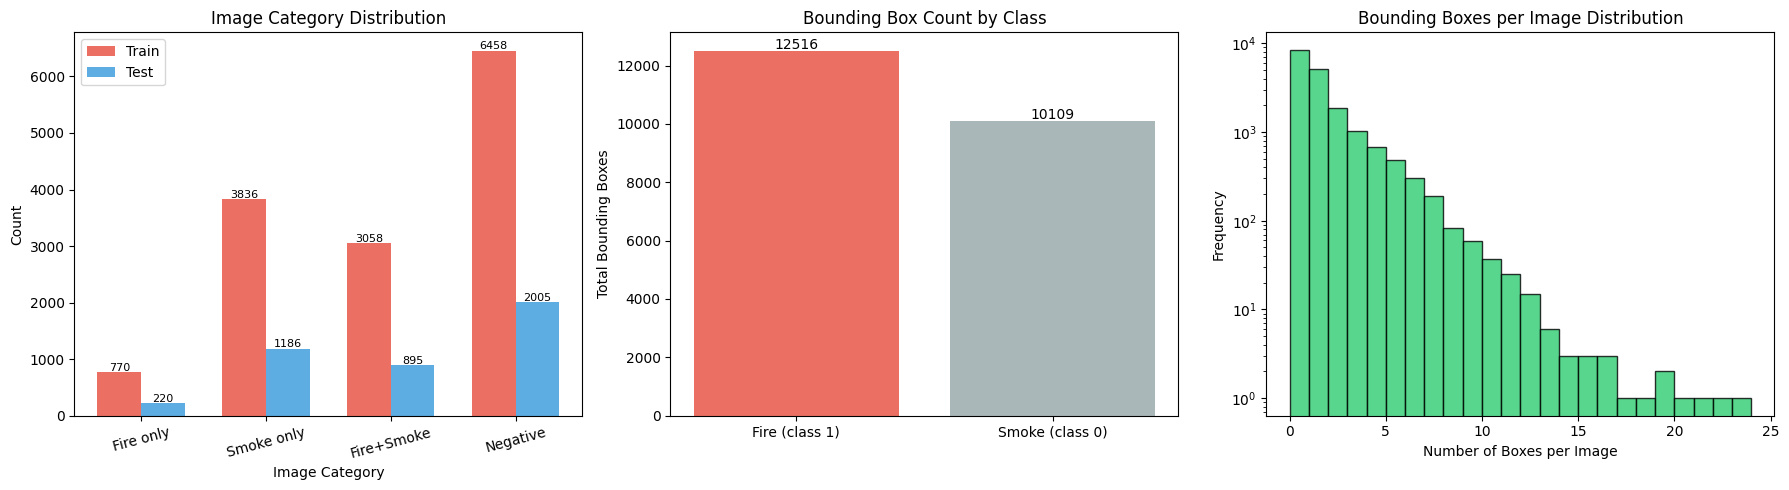

Saved: class_distribution.png


In [4]:
if os.path.isdir(train_img_dir):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # --- Plot 1: Image categories (train vs test) ---
    categories = ['Fire only', 'Smoke only', 'Fire+Smoke', 'Negative']
    train_counts = [train_stats['fire_only'], train_stats['smoke_only'], 
                    train_stats['fire_and_smoke'], train_stats['negative']]
    test_counts  = [test_stats['fire_only'], test_stats['smoke_only'], 
                    test_stats['fire_and_smoke'], test_stats['negative']]
    
    x = np.arange(len(categories))
    width = 0.35
    axes[0].bar(x - width/2, train_counts, width, label='Train', color='#e74c3c', alpha=0.8)
    axes[0].bar(x + width/2, test_counts, width, label='Test', color='#3498db', alpha=0.8)
    axes[0].set_xlabel('Image Category')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Image Category Distribution')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(categories, rotation=15)
    axes[0].legend()
    for i, (tr, te) in enumerate(zip(train_counts, test_counts)):
        axes[0].text(i - width/2, tr + 20, str(tr), ha='center', fontsize=8)
        axes[0].text(i + width/2, te + 20, str(te), ha='center', fontsize=8)
    
    # --- Plot 2: Bounding box class distribution ---
    all_fire  = train_stats['total_fire_boxes'] + test_stats['total_fire_boxes']
    all_smoke = train_stats['total_smoke_boxes'] + test_stats['total_smoke_boxes']
    axes[1].bar(['Fire (class 1)', 'Smoke (class 0)'], [all_fire, all_smoke], 
                color=['#e74c3c', '#95a5a6'], alpha=0.8)
    axes[1].set_ylabel('Total Bounding Boxes')
    axes[1].set_title('Bounding Box Count by Class')
    axes[1].text(0, all_fire + 50, str(all_fire), ha='center', fontsize=10)
    axes[1].text(1, all_smoke + 50, str(all_smoke), ha='center', fontsize=10)
    
    # --- Plot 3: Boxes per image histogram ---
    all_bpi = train_stats['boxes_per_image'] + test_stats['boxes_per_image']
    axes[2].hist(all_bpi, bins=range(0, max(all_bpi)+2), color='#2ecc71', alpha=0.8, edgecolor='black')
    axes[2].set_xlabel('Number of Boxes per Image')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title('Bounding Boxes per Image Distribution')
    axes[2].set_yscale('log')
    
    plt.tight_layout()
    plt.savefig("class_distribution.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: class_distribution.png")


### 4.2 Bounding Box Size Analysis

This is critical for our project: small bounding boxes correspond to distant fires/smoke — exactly the regime where YOLO struggles and where our CLIP verification module must operate on low-resolution crops.


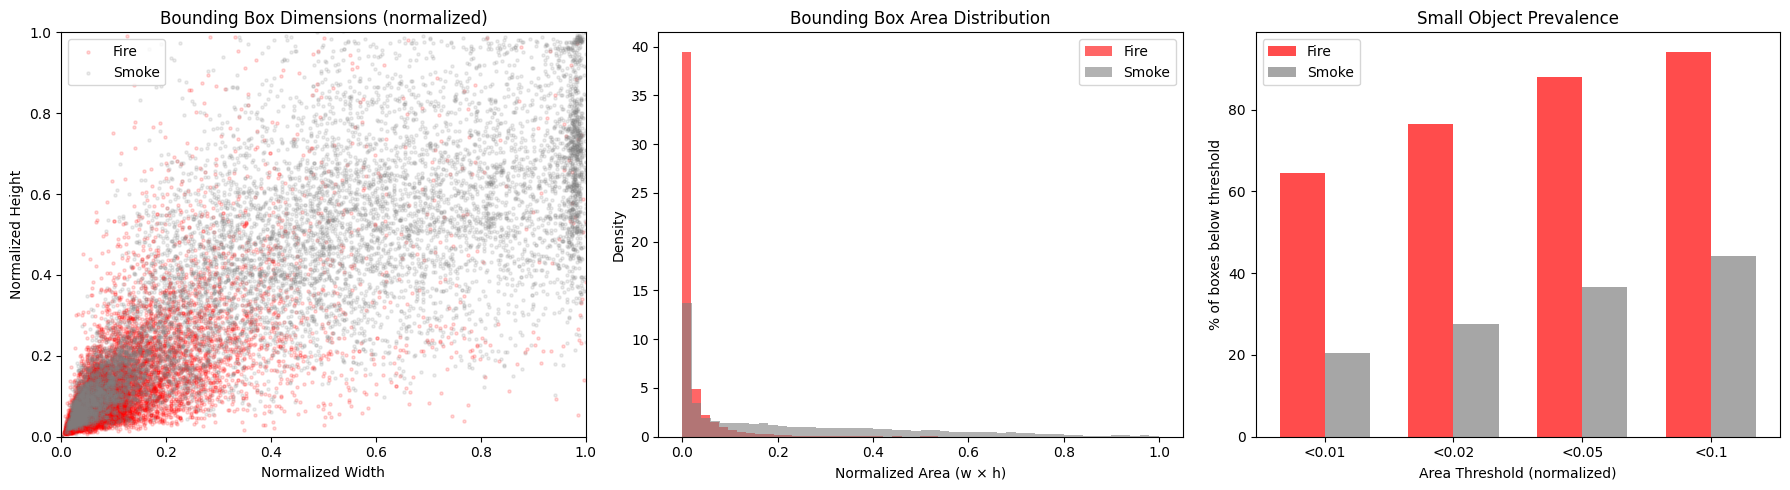


Fire boxes:  median area = 0.0054, mean = 0.0245
Smoke boxes: median area = 0.1405, mean = 0.2256

Fire boxes < 1% image area:  8069 (64.5%)
Smoke boxes < 1% image area: 2075 (20.5%)


In [5]:
if os.path.isdir(train_img_dir):
    all_sizes = train_stats['box_sizes'] + test_stats['box_sizes']
    all_cls   = train_stats['class_ids'] + test_stats['class_ids']
    
    fire_w  = [s[0] for s, c in zip(all_sizes, all_cls) if c == 1]
    fire_h  = [s[1] for s, c in zip(all_sizes, all_cls) if c == 1]
    smoke_w = [s[0] for s, c in zip(all_sizes, all_cls) if c == 0]
    smoke_h = [s[1] for s, c in zip(all_sizes, all_cls) if c == 0]
    
    fire_area  = [w * h for w, h in zip(fire_w, fire_h)]
    smoke_area = [w * h for w, h in zip(smoke_w, smoke_h)]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Scatter: width vs height
    axes[0].scatter(fire_w, fire_h, alpha=0.15, s=5, c='red', label='Fire')
    axes[0].scatter(smoke_w, smoke_h, alpha=0.15, s=5, c='gray', label='Smoke')
    axes[0].set_xlabel('Normalized Width')
    axes[0].set_ylabel('Normalized Height')
    axes[0].set_title('Bounding Box Dimensions (normalized)')
    axes[0].legend()
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    
    # Area distribution
    axes[1].hist(fire_area, bins=50, alpha=0.6, color='red', label='Fire', density=True)
    axes[1].hist(smoke_area, bins=50, alpha=0.6, color='gray', label='Smoke', density=True)
    axes[1].set_xlabel('Normalized Area (w × h)')
    axes[1].set_ylabel('Density')
    axes[1].set_title('Bounding Box Area Distribution')
    axes[1].legend()
    
    # Small object analysis
    thresholds = [0.01, 0.02, 0.05, 0.10]
    fire_pcts  = [sum(1 for a in fire_area if a < t) / len(fire_area) * 100 for t in thresholds]
    smoke_pcts = [sum(1 for a in smoke_area if a < t) / len(smoke_area) * 100 for t in thresholds]
    
    x = np.arange(len(thresholds))
    width = 0.35
    axes[2].bar(x - width/2, fire_pcts, width, label='Fire', color='red', alpha=0.7)
    axes[2].bar(x + width/2, smoke_pcts, width, label='Smoke', color='gray', alpha=0.7)
    axes[2].set_xlabel('Area Threshold (normalized)')
    axes[2].set_ylabel('% of boxes below threshold')
    axes[2].set_title('Small Object Prevalence')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels([f'<{t}' for t in thresholds])
    axes[2].legend()
    
    plt.tight_layout()
    plt.savefig("bbox_analysis.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nFire boxes:  median area = {np.median(fire_area):.4f}, mean = {np.mean(fire_area):.4f}")
    print(f"Smoke boxes: median area = {np.median(smoke_area):.4f}, mean = {np.mean(smoke_area):.4f}")
    print(f"\nFire boxes < 1% image area:  {sum(1 for a in fire_area if a < 0.01)} ({sum(1 for a in fire_area if a < 0.01)/len(fire_area)*100:.1f}%)")
    print(f"Smoke boxes < 1% image area: {sum(1 for a in smoke_area if a < 0.01)} ({sum(1 for a in smoke_area if a < 0.01)/len(smoke_area)*100:.1f}%)")


## 5. Sample Images with Bounding Box Annotations

Visualizing annotated samples from D-Fire across all categories: fire-only, smoke-only, fire+smoke, and negative (hard negative) images.


In [6]:
CLASS_COLORS = {0: 'cyan', 1: 'red'}
CLASS_NAMES  = {0: 'Smoke', 1: 'Fire'}

def load_yolo_labels(lbl_path):
    """Parse YOLO-format label file. Returns list of (class_id, x_c, y_c, w, h)."""
    boxes = []
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    boxes.append((int(parts[0]), float(parts[1]), float(parts[2]),
                                  float(parts[3]), float(parts[4])))
    return boxes

def draw_annotations(ax, img, boxes, title=""):
    """Draw image with YOLO bounding boxes."""
    ax.imshow(img)
    h, w = img.shape[:2] if hasattr(img, 'shape') else (img.size[1], img.size[0])
    
    # Convert PIL to numpy if needed
    if not hasattr(img, 'shape'):
        w, h = img.size
    else:
        h, w = img.shape[:2]
    
    for cls_id, xc, yc, bw, bh in boxes:
        # Convert normalized YOLO coords to pixel coords
        x1 = (xc - bw / 2) * w
        y1 = (yc - bh / 2) * h
        box_w = bw * w
        box_h = bh * h
        
        rect = patches.Rectangle((x1, y1), box_w, box_h, 
                                  linewidth=2, edgecolor=CLASS_COLORS.get(cls_id, 'yellow'),
                                  facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, CLASS_NAMES.get(cls_id, f'cls_{cls_id}'),
                color='white', fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor=CLASS_COLORS.get(cls_id, 'yellow'),
                          alpha=0.7))
    
    ax.set_title(title, fontsize=10)
    ax.axis('off')

def find_images_by_category(img_dir, lbl_dir):
    """Categorize images into fire_only, smoke_only, both, negative."""
    categories = {'fire_only': [], 'smoke_only': [], 'both': [], 'negative': []}
    img_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
    
    for img_name in os.listdir(img_dir):
        if not img_name.lower().endswith(img_extensions):
            continue
        base = os.path.splitext(img_name)[0]
        lbl_path = os.path.join(lbl_dir, base + ".txt")
        boxes = load_yolo_labels(lbl_path)
        
        classes_present = set(b[0] for b in boxes)
        
        if 0 in classes_present and 1 in classes_present:
            categories['both'].append(img_name)
        elif 0 in classes_present:
            categories['smoke_only'].append(img_name)
        elif 1 in classes_present:
            categories['fire_only'].append(img_name)
        else:
            categories['negative'].append(img_name)
    
    return categories

print("Helper functions defined.")


Helper functions defined.


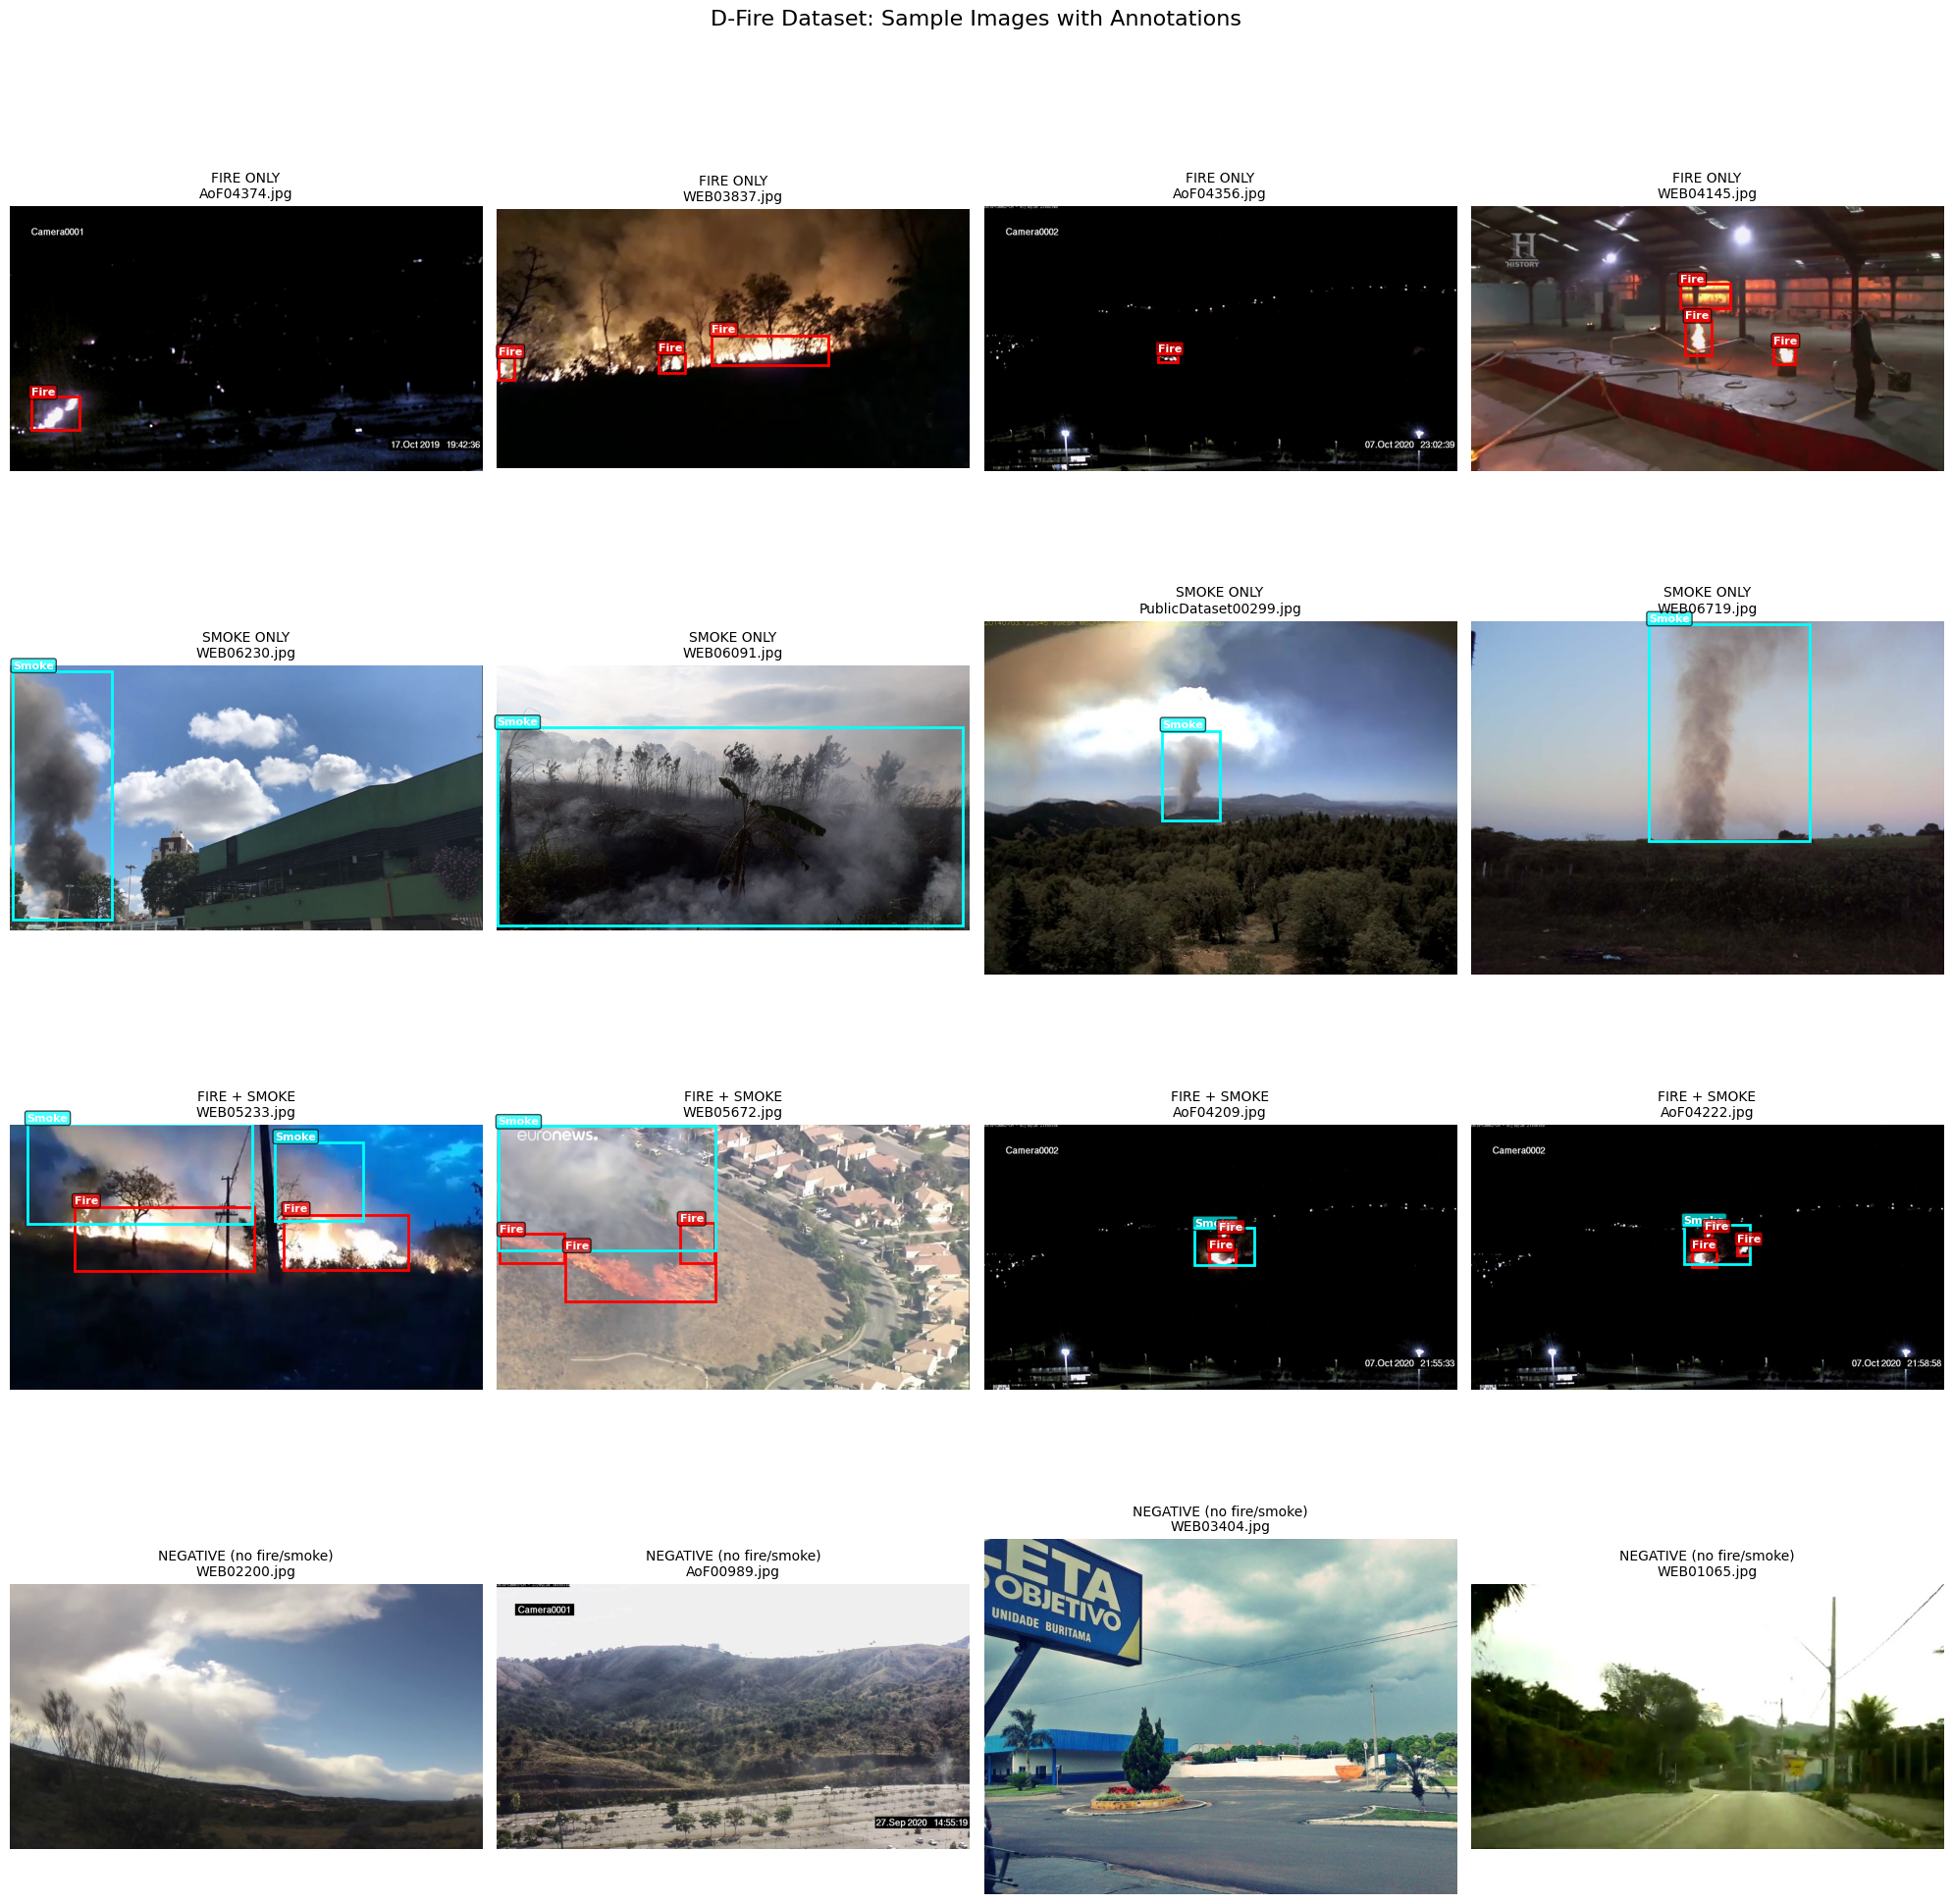

Saved: sample_annotations.png


In [7]:
if os.path.isdir(train_img_dir):
    cats = find_images_by_category(train_img_dir, train_lbl_dir)
    
    fig, axes = plt.subplots(4, 4, figsize=(20, 20))
    
    category_order = [
        ('fire_only',  'FIRE ONLY'),
        ('smoke_only', 'SMOKE ONLY'),
        ('both',       'FIRE + SMOKE'),
        ('negative',   'NEGATIVE (no fire/smoke)')
    ]
    
    for row_idx, (cat_key, cat_title) in enumerate(category_order):
        samples = random.sample(cats[cat_key], min(4, len(cats[cat_key])))
        for col_idx, img_name in enumerate(samples):
            img_path = os.path.join(train_img_dir, img_name)
            lbl_path = os.path.join(train_lbl_dir, os.path.splitext(img_name)[0] + ".txt")
            
            img = Image.open(img_path).convert('RGB')
            boxes = load_yolo_labels(lbl_path)
            
            title = f"{cat_title}\n{img_name}"
            draw_annotations(axes[row_idx, col_idx], img, boxes, title)
    
    plt.suptitle("D-Fire Dataset: Sample Images with Annotations", fontsize=16, y=1.01)
    plt.tight_layout()
    plt.savefig("sample_annotations.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: sample_annotations.png")


### 5.1 Image Resolution Distribution

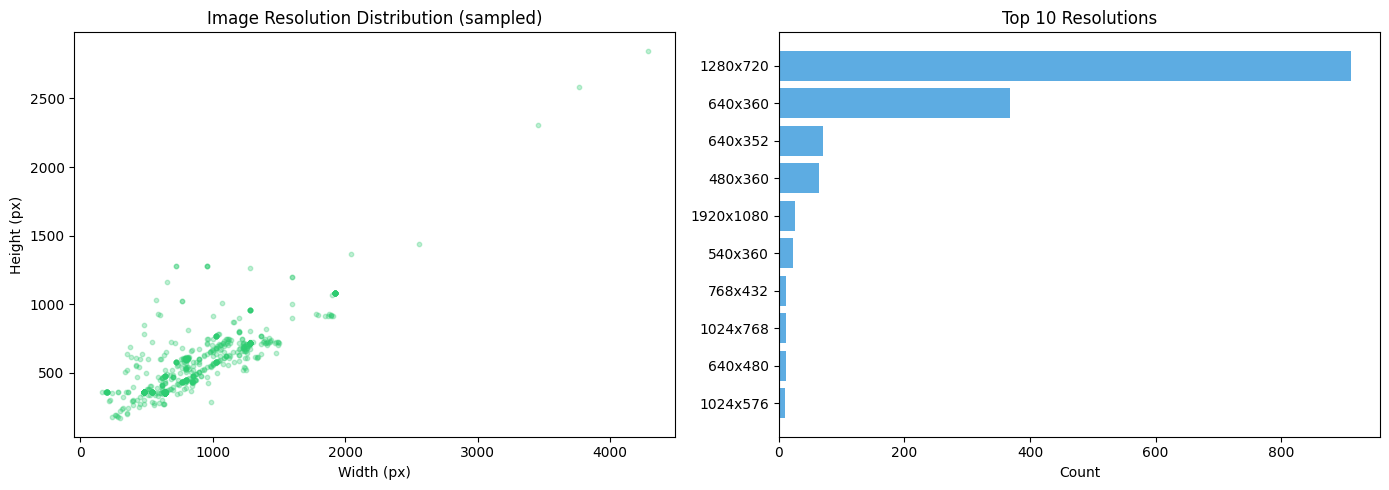

Unique resolutions in sample: 419
Most common: 1280x720 (912 images)


In [8]:
if os.path.isdir(train_img_dir):
    resolutions = []
    img_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
    all_images = [f for f in os.listdir(train_img_dir) if f.lower().endswith(img_extensions)]
    
    # Sample for speed
    sample_imgs = random.sample(all_images, min(2000, len(all_images)))
    
    for img_name in sample_imgs:
        img = Image.open(os.path.join(train_img_dir, img_name))
        resolutions.append(img.size)  # (width, height)
    
    widths  = [r[0] for r in resolutions]
    heights = [r[1] for r in resolutions]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].scatter(widths, heights, alpha=0.3, s=10, c='#2ecc71')
    axes[0].set_xlabel('Width (px)')
    axes[0].set_ylabel('Height (px)')
    axes[0].set_title('Image Resolution Distribution (sampled)')
    
    unique_res = Counter(resolutions)
    top_res = unique_res.most_common(10)
    labels = [f"{w}x{h}" for (w, h), _ in top_res]
    counts = [c for _, c in top_res]
    axes[1].barh(labels, counts, color='#3498db', alpha=0.8)
    axes[1].set_xlabel('Count')
    axes[1].set_title('Top 10 Resolutions')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.savefig("resolution_distribution.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Unique resolutions in sample: {len(unique_res)}")
    print(f"Most common: {top_res[0][0][0]}x{top_res[0][0][1]} ({top_res[0][1]} images)")


## 6. Annotation Quality Checks

Verifying annotation integrity: checking for malformed labels, out-of-bound coordinates, and orphaned files.


In [9]:
def check_annotation_quality(img_dir, lbl_dir, split_name=""):
    """Run quality checks on annotations."""
    img_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
    images = set(os.path.splitext(f)[0] for f in os.listdir(img_dir) if f.lower().endswith(img_extensions))
    labels = set(os.path.splitext(f)[0] for f in os.listdir(lbl_dir) if f.endswith('.txt'))
    
    issues = {
        'images_without_labels': images - labels,
        'labels_without_images': labels - images,
        'malformed_lines': 0,
        'out_of_bounds': 0,
        'empty_label_files': 0,
        'total_label_files': len(labels),
        'unknown_classes': Counter()
    }
    
    for lbl_name in labels:
        lbl_path = os.path.join(lbl_dir, lbl_name + ".txt")
        with open(lbl_path, 'r') as f:
            lines = f.readlines()
        
        non_empty = [l.strip() for l in lines if l.strip()]
        if len(non_empty) == 0:
            issues['empty_label_files'] += 1
            continue
        
        for line in non_empty:
            parts = line.split()
            if len(parts) < 5:
                issues['malformed_lines'] += 1
                continue
            
            try:
                cls_id = int(parts[0])
                xc, yc, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                
                if cls_id not in (0, 1):
                    issues['unknown_classes'][cls_id] += 1
                
                if not (0 <= xc <= 1 and 0 <= yc <= 1 and 0 < w <= 1 and 0 < h <= 1):
                    issues['out_of_bounds'] += 1
            except ValueError:
                issues['malformed_lines'] += 1
    
    print(f"\n{'=' * 50}")
    print(f"ANNOTATION QUALITY CHECK: {split_name}")
    print(f"{'=' * 50}")
    print(f"Images without label files: {len(issues['images_without_labels'])}")
    print(f"Label files without images: {len(issues['labels_without_images'])}")
    print(f"Empty label files (negatives): {issues['empty_label_files']}")
    print(f"Malformed annotation lines: {issues['malformed_lines']}")
    print(f"Out-of-bounds coordinates: {issues['out_of_bounds']}")
    if issues['unknown_classes']:
        print(f"Unknown class IDs: {dict(issues['unknown_classes'])}")
    else:
        print(f"Unknown class IDs: None (all labels are 0 or 1)")
    
    if issues['malformed_lines'] == 0 and issues['out_of_bounds'] < 50 and len(issues['labels_without_images']) == 0:
        print("\n✓ No critical issues found.")
    else:
        print("\n⚠ Issues detected — review before training.")
    
    return issues

if os.path.isdir(train_img_dir):
    train_issues = check_annotation_quality(train_img_dir, train_lbl_dir, "TRAIN")
    val_issues   = check_annotation_quality(val_img_dir, val_lbl_dir, "VAL")
    test_issues  = check_annotation_quality(test_img_dir, test_lbl_dir, "TEST")


ANNOTATION QUALITY CHECK: TRAIN
Images without label files: 0
Label files without images: 0
Empty label files (negatives): 6458
Malformed annotation lines: 0
Out-of-bounds coordinates: 13
Unknown class IDs: None (all labels are 0 or 1)

✓ No critical issues found.

ANNOTATION QUALITY CHECK: VAL
Images without label files: 0
Label files without images: 0
Empty label files (negatives): 1375
Malformed annotation lines: 0
Out-of-bounds coordinates: 1
Unknown class IDs: None (all labels are 0 or 1)

✓ No critical issues found.

ANNOTATION QUALITY CHECK: TEST
Images without label files: 0
Label files without images: 0
Empty label files (negatives): 2005
Malformed annotation lines: 0
Out-of-bounds coordinates: 12
Unknown class IDs: None (all labels are 0 or 1)

✓ No critical issues found.


## 7. FASDD Dataset (Secondary Benchmark)

**Full Name:** Fire And Smoke Detection Dataset  
**Size:** 100,000+ images  
**Modality:** RGB images from heterogeneous sources (indoor, outdoor, satellite, surveillance)

### 7.1 Key Properties

| Property | Value |
|----------|-------|
| Total images | 100,000+ |
| Classes | Fire, Smoke, Normal |
| Annotation type | Image-level classification labels |
| Sources | Internet scraping, existing datasets, surveillance feeds |
| Special value | Indoor + outdoor + satellite scenes in a single dataset |

### 7.2 Relevance to Our Project

FASDD is relevant as a **secondary** evaluation benchmark because:
- It includes heterogeneous scene types (indoor, outdoor, satellite, surveillance) which stress-test generalization.
- Its classification-level labels (no bounding boxes) mean we cannot use it for detection evaluation, but we **can** use it for evaluating our CLIP verification module independently — since CLIP operates on image-level or crop-level semantic classification.
- The "Normal" class may contain fog, haze, and cloud scenes that serve as natural hard negatives.

### 7.3 Limitations

- No bounding-box annotations → cannot compute detection mAP.
- Dataset quality is inconsistent due to web scraping.
- May overlap with D-Fire images (no deduplication guarantees).

> **Note:** If FASDD access is restricted or download is impractical for submission, D-Fire serves as the sole detection benchmark. FASDD would be used only for CLIP module validation.


## 8. WWF PTZ Camera Dataset (Custom / In Progress)

### 8.1 Description

This dataset consists of frames extracted from Pan-Tilt-Zoom (PTZ) camera feeds deployed by WWF in forest areas. The footage is being collected as part of an ongoing collaboration.

### 8.2 Properties

| Property | Value |
|----------|-------|
| Source | WWF forest monitoring PTZ cameras |
| Modality | RGB video frames |
| Resolution | Variable (depends on PTZ zoom level) |
| Annotation status | **Pending** — will require manual bounding-box annotation |
| Key characteristic | Contains natural fog, haze, variable lighting, and weather conditions endemic to real deployment |

### 8.3 Custom Annotation Plan

If/when PTZ footage becomes available, the annotation workflow is:

1. **Frame extraction:** Sample frames at 1 FPS from video to avoid temporal redundancy (consecutive frames are near-identical).
2. **Annotation tool:** Use [LabelImg](https://github.com/HumanSignal/labelImg) or [CVAT](https://www.cvat.ai/) for bounding-box annotation in YOLO format.
3. **Class schema:** Identical to D-Fire — class 0 = Smoke, class 1 = Fire.
4. **Hard negative labeling:** Frames with fog, haze, clouds, or sunlight are retained as negatives (empty label files) to explicitly train and test against false-positive-inducing conditions.
5. **Quality assurance:** Each frame annotated by one person, reviewed by the second group member. Disagreements resolved by consensus.
6. **Split strategy:** 70% train / 15% val / 15% test, with temporal separation (no frames from the same video segment appearing in both train and test).

> **Current status:** Awaiting footage delivery from WWF. If not available before project deadline, all quantitative evaluation will use D-Fire (detection) and optionally FASDD (CLIP module validation).


## 9. Train/Test/val Split Summary

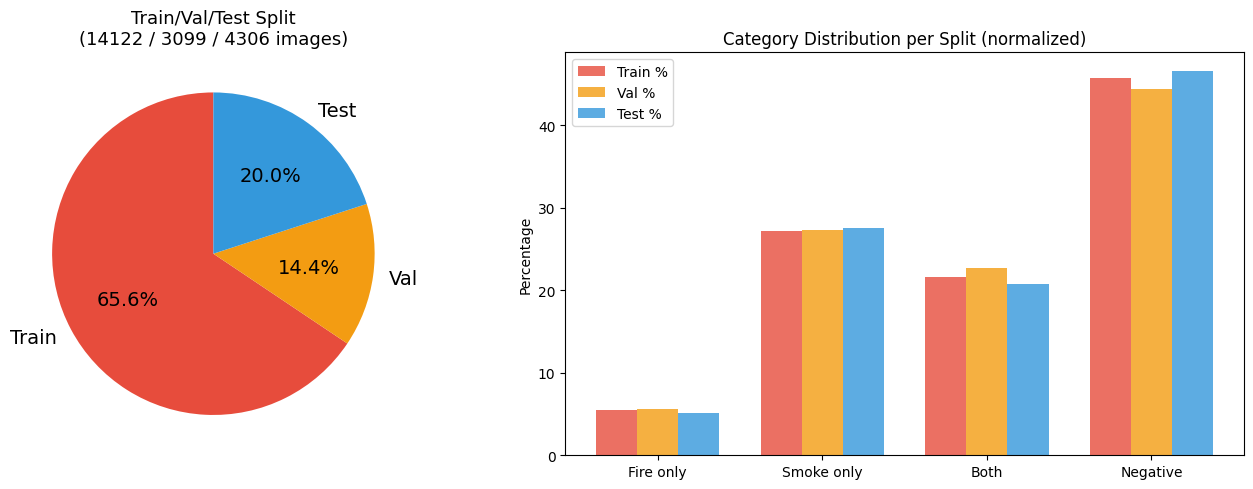

In [10]:
if os.path.isdir(train_img_dir):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sizes = [train_stats['total_images'], val_stats['total_images'], test_stats['total_images']]
    axes[0].pie(sizes, labels=['Train', 'Val', 'Test'], autopct='%1.1f%%', startangle=90,
                colors=['#e74c3c', '#f39c12', '#3498db'], textprops={'fontsize': 14})
    axes[0].set_title(f'Train/Val/Test Split\n({sizes[0]} / {sizes[1]} / {sizes[2]} images)', fontsize=13)
    
    categories = ['Fire only', 'Smoke only', 'Both', 'Negative']
    train_vals = [train_stats['fire_only'], train_stats['smoke_only'],
                  train_stats['fire_and_smoke'], train_stats['negative']]
    val_vals   = [val_stats['fire_only'], val_stats['smoke_only'],
                  val_stats['fire_and_smoke'], val_stats['negative']]
    test_vals  = [test_stats['fire_only'], test_stats['smoke_only'],
                  test_stats['fire_and_smoke'], test_stats['negative']]
    
    train_pct = [v / sum(train_vals) * 100 for v in train_vals]
    val_pct   = [v / sum(val_vals) * 100 for v in val_vals]
    test_pct  = [v / sum(test_vals) * 100 for v in test_vals]
    
    x = np.arange(len(categories))
    width = 0.25
    axes[1].bar(x - width, train_pct, width, label='Train %', color='#e74c3c', alpha=0.8)
    axes[1].bar(x, val_pct, width, label='Val %', color='#f39c12', alpha=0.8)
    axes[1].bar(x + width, test_pct, width, label='Test %', color='#3498db', alpha=0.8)
    axes[1].set_ylabel('Percentage')
    axes[1].set_title('Category Distribution per Split (normalized)')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(categories)
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig("split_summary.png", dpi=150, bbox_inches='tight')
    plt.show()

## 10. Dataset–Project Alignment

### Why D-Fire is the right primary benchmark

| Requirement from SOA Survey | D-Fire Suitability |
|---|---|
| Bounding-box annotations for detection | Yes — YOLO-format boxes for fire and smoke |
| Hard negatives (fog, sunlight, reflections) | Yes — includes lamp lights, sun glare, reflective surfaces |
| Sufficient scale for training YOLOv8 | Yes — 21.5k images with standard train/test split |
| Multi-class (fire vs smoke) | Yes — class 0 = Smoke and class 1 = Fire |
| Compatible with CLIP verification evaluation | Yes — detected crops can be fed to CLIP for semantic filtering |

### Key observation from the data exploration

The negative (no-annotation) images in D-Fire are critical for our project. These include scenes with fire-like and smoke-like visual patterns that are **not** fire or smoke — exactly the false-positive-inducing confounders our CLIP semantic verification module targets. The proportion and diversity of these negatives directly determines how meaningfully we can measure false positive reduction.

### What the data tells us about the CLIP verification design

The bounding box size analysis (Section 4.2) reveals that a significant fraction of boxes are small. When YOLO detects a small region and crops it for CLIP verification, the resulting crop will be low-resolution. This means:
- CLIP ViT-B/32 (224×224 input) may receive very blurry crops for small detections.
- We may need to include surrounding context (expand the crop by a margin) before feeding to CLIP.
- The accuracy–latency trade-off between ViT-B/32 and ViT-L/14 becomes more important for small objects.


## 11. Summary

| Dataset | Role | Images | Classes | Annotation Type | Status |
|---------|------|--------|---------|----------------|--------|
| D-Fire | Primary detection benchmark | 21,527 | 2 (fire, smoke) | YOLO bounding boxes | Ready |
| FASDD | CLIP module validation | 100k+ | 3 (fire, smoke, normal) | Image-level labels | Available |
| WWF PTZ | Real-world deployment test | TBD | 2 (fire, smoke) | Manual bbox (pending) | Awaiting footage |

The D-Fire dataset is well-suited to our project objectives. Its inclusion of hard negatives, YOLO-format annotations, and two-class labeling directly supports the YOLO+CLIP pipeline we propose. The annotation quality checks confirm the dataset is clean and ready for training.
